In [346]:
# Import necessary libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_curve, auc

# Load the raw dataset
df = pd.read_csv("meyer.csv")
print("Initial DataFrame shape:", df.shape)
df.head()

Initial DataFrame shape: (243, 15)


,moisture,spring_stiffness,displacement_screw_setting,motor_speed,untouched,longitudinal less than 25%,Longitudinal between 25-50%,Longitudinal between 50-75%,Longitudinal more than 75%,Circumferential less than 25%,Circumferential between 25-50%,Circumferential between 50-75%,Circumferential more than 75%,Open Crack,Crushed
0,5,1800,0.29,60,NaN,NaN,NaN,NaN,"*GH013810, *GH013811, *GH013812, *GH013813, *G...",NaN,"*GH013812, *GH013813, *GH013814",NaN,"*GH013810, *GH013811, *GH013815","*GH013810, *GH013811, *GH013812, *GH013813, *G...",NaN
1,5,1800,0.22,45,NaN,NaN,NaN,NaN,"*GH013816, *GH013817, *GH013818, *GH013819, *G...",NaN,*GH013818,*GH013821,"*GH013816, *GH013817, *GH013819, *GH013820","*GH013816, *GH013817, *GH013818, *GH013819, *G...",NaN
2,5,1800,0.36,30,*GH013822,NaN,NaN,*GH013823,"*GH013824, *GH013825, *GH013826, *GH013827","*GH013823, *GH013826",NaN,"*GH013824, *GH013827",*GH013825,"*GH013823, *GH013824, *GH013825, *GH013827",NaN
3,5,1800,0.36,60,*GH013832,NaN,NaN,NaN,"*GH013828, *GH013829, *GH013830, *GH013831, *G...",*GH013829,"*GH013830, *GH013833",*GH013828,*GH013831,"*GH013828, *GH013830, *GH013831, *GH013833",NaN
4,5,1800,0.22,30,NaN,NaN,NaN,NaN,"*GH013834, *GH013835, *GH013836, *GH013837, *G...",NaN,NaN,*GH013836,"*GH013834, *GH013835, *GH013837, *GH013838, *G...","*GH013834, *GH013835, *GH013836, *GH013837, *G...",NaN


In [347]:
# Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_").str.replace("-", "_")
print("Renamed columns:", df.columns.tolist())

Renamed columns: ['moisture', 'spring_stiffness', 'displacement_screw_setting', 'motor_speed', 'untouched', 'longitudinal_less_than_25%', 'longitudinal_between_25_50%', 'longitudinal_between_50_75%', 'longitudinal_more_than_75%', 'circumferential_less_than_25%', 'circumferential_between_25_50%', 'circumferential_between_50_75%', 'circumferential_more_than_75%', 'open_crack', 'crushed']


In [348]:
# Define factor columns and convert them to numeric
factor_cols = ["moisture", "spring_stiffness", "displacement_screw_setting", "motor_speed"]
for col in factor_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print("Missing values in factor columns:")
print(df[factor_cols].isnull().sum())

Missing values in factor columns:
moisture                      0
spring_stiffness              0
displacement_screw_setting    0
motor_speed                   0
dtype: int64


In [349]:
# Identify crack outcome columns
crack_cols = [c for c in df.columns if c not in factor_cols]
print("Crack columns identified:", crack_cols)

Crack columns identified: ['untouched', 'longitudinal_less_than_25%', 'longitudinal_between_25_50%', 'longitudinal_between_50_75%', 'longitudinal_more_than_75%', 'circumferential_less_than_25%', 'circumferential_between_25_50%', 'circumferential_between_50_75%', 'circumferential_more_than_75%', 'open_crack', 'crushed']


In [350]:
# Define functions to extract video IDs from a cell and count unique video IDs across crack columns.
def extract_video_ids(cell_value: str) -> list:
    if pd.isna(cell_value):
        return []
    return [x.strip() for x in cell_value.split(",") if x.strip() != ""]


def count_unique_videos(row: pd.Series) -> int:
    all_ids = []
    for col in crack_cols:
        all_ids.extend(extract_video_ids(row[col]))
    return len(set(all_ids))

In [351]:
# Compute unique video counts for each row and flag incomplete runs
df["video_count"] = df.apply(count_unique_videos, axis=1)
df["missing_videos_flag"] = df["video_count"] < 6
print(df[["video_count", "missing_videos_flag"]].head(10))
print(f"Number of runs with fewer than 6 videos: {df['missing_videos_flag'].sum()}")

   video_count  missing_videos_flag
0            6                False
1            6                False
2            6                False
3            6                False
4            6                False
5            5                 True
6            6                False
7            6                False
8            6                False
9            6                False
Number of runs with fewer than 6 videos: 16


In [352]:
# Verify that factor columns contain the expected values.

# %%
print("Motor Speed values:", df["motor_speed"].unique())  # Expected: [30, 45, 60]
print("Moisture values:", df["moisture"].unique())  # Expected: [5, 7, 9]
print("Displacement Screw Setting values:", df["displacement_screw_setting"].unique())  # Expected: [0.22, 0.29, 0.36]
print("Spring Stiffness values:", df["spring_stiffness"].unique())  # Expected: [1800, 2000, 2200]

Motor Speed values: [60 45 30]
Moisture values: [5 7 9]
Displacement Screw Setting values: [0.29 0.22 0.36]
Spring Stiffness values: [1800 2000 2200]


In [353]:
# Create long-format records: one row per video ID with its corresponding factor values and crack type.
records = []
for idx, row in df.iterrows():
    # Extract factor values for the run
    factors = {col: row[col] for col in factor_cols}
    # Iterate through each crack outcome column and extract video IDs
    for col in crack_cols:
        video_ids = extract_video_ids(row[col])
        for vid in video_ids:
            record = factors.copy()
            record["video_id"] = vid
            record["crack_type"] = col  # Original crack category name
            records.append(record)

df_long = pd.DataFrame(records)
print("Long-format DataFrame shape:", df_long.shape)
df_long.head(10)

Long-format DataFrame shape: (3769, 6)


,moisture,spring_stiffness,displacement_screw_setting,motor_speed,video_id,crack_type
0,5,1800,0.29,60,*GH013810,longitudinal_more_than_75%
1,5,1800,0.29,60,*GH013811,longitudinal_more_than_75%
2,5,1800,0.29,60,*GH013812,longitudinal_more_than_75%
3,5,1800,0.29,60,*GH013813,longitudinal_more_than_75%
4,5,1800,0.29,60,*GH013814,longitudinal_more_than_75%
5,5,1800,0.29,60,*GH013815,longitudinal_more_than_75%
6,5,1800,0.29,60,*GH013812,circumferential_between_25_50%
7,5,1800,0.29,60,*GH013813,circumferential_between_25_50%
8,5,1800,0.29,60,*GH013814,circumferential_between_25_50%
9,5,1800,0.29,60,*GH013810,circumferential_more_than_75%


In [354]:
# Pivot the long-format data with 'video_id' and factors as the index, and crack_type as columns.
df_aggregated = df_long.pivot_table(index=["video_id", "moisture", "spring_stiffness", "displacement_screw_setting", "motor_speed"], columns="crack_type", values="crack_type", aggfunc=lambda x: 1, fill_value=0).reset_index()

# Print raw aggregated column names
print("Raw aggregated columns:", df_aggregated.columns.tolist())

Raw aggregated columns: ['video_id', 'moisture', 'spring_stiffness', 'displacement_screw_setting', 'motor_speed', 'circumferential_between_25_50%', 'circumferential_between_50_75%', 'circumferential_less_than_25%', 'circumferential_more_than_75%', 'crushed', 'longitudinal_between_25_50%', 'longitudinal_between_50_75%', 'longitudinal_less_than_25%', 'longitudinal_more_than_75%', 'open_crack', 'untouched']


In [355]:
# Expected factor names:
expected_factor_cols = ["video", "moisture", "spring", "displacement", "motor"]

# Get current aggregated columns as a list
current_cols = df_aggregated.columns.tolist()

# Replace the first five columns with our desired factor names.
for i in range(len(expected_factor_cols)):
    current_cols[i] = expected_factor_cols[i]
df_aggregated.columns = current_cols
print("After reassigning factor names:")
print(df_aggregated.columns.tolist())

# Print remaining crack outcome columns (raw)
print("Raw crack outcome columns:", df_aggregated.columns[5:])

# Define renaming dictionary for crack outcomes:
rename_dict = {"untouched": "U", "longitudinal_less_than_25%": "L_1", "longitudinal_between_25_50%": "L_2", "longitudinal_between_50_75%": "L_3", "longitudinal_more_than_75%": "L_4", "circumferential_less_than_25%": "C_1", "circumferential_between_25_50%": "C_2", "circumferential_between_50_75%": "C_3", "circumferential_more_than_75%": "C_4", "open_crack": "O", "crushed": "X"}

# Rename crack outcome columns (columns 6 onward)
new_crack_cols = [rename_dict.get(col, col) for col in df_aggregated.columns[5:]]
# Combine factor columns with renamed crack outcome columns
df_aggregated.columns = expected_factor_cols + new_crack_cols
print("Columns after renaming crack outcomes:")
print(df_aggregated.columns.tolist())

After reassigning factor names:
['video', 'moisture', 'spring', 'displacement', 'motor', 'circumferential_between_25_50%', 'circumferential_between_50_75%', 'circumferential_less_than_25%', 'circumferential_more_than_75%', 'crushed', 'longitudinal_between_25_50%', 'longitudinal_between_50_75%', 'longitudinal_less_than_25%', 'longitudinal_more_than_75%', 'open_crack', 'untouched']
Raw crack outcome columns: Index(['circumferential_between_25_50%', 'circumferential_between_50_75%',
       'circumferential_less_than_25%', 'circumferential_more_than_75%',
       'crushed', 'longitudinal_between_25_50%', 'longitudinal_between_50_75%',
       'longitudinal_less_than_25%', 'longitudinal_more_than_75%',
       'open_crack', 'untouched'],
      dtype='object')
Columns after renaming crack outcomes:
['video', 'moisture', 'spring', 'displacement', 'motor', 'C_2', 'C_3', 'C_1', 'C_4', 'X', 'L_2', 'L_3', 'L_1', 'L_4', 'O', 'U']


In [356]:
# Define desired order for crack outcome columns
desired_order = ["U", "L_1", "L_2", "L_3", "L_4", "C_1", "C_2", "C_3", "C_4", "O", "X"]
# Factor columns remain as defined
factor_order = expected_factor_cols
# Extract current crack outcome columns (from index 5 onward)
current_crack_cols = df_aggregated.columns.tolist()[5:]
# Reorder crack outcome columns based on desired order (only include those present)
new_crack_cols_ordered = [col for col in desired_order if col in current_crack_cols]
# Combine factor columns with the newly ordered crack outcome columns
new_column_order = factor_order + new_crack_cols_ordered
df_aggregated = df_aggregated[new_column_order]
print("Final aggregated binary column order:")
print(df_aggregated.columns.tolist())

Final aggregated binary column order:
['video', 'moisture', 'spring', 'displacement', 'motor', 'U', 'L_1', 'L_2', 'L_3', 'L_4', 'C_1', 'C_2', 'C_3', 'C_4', 'O', 'X']


In [357]:
# Save the final aggregated binary dataset with the desired column names to a single CSV file.
df_aggregated.to_csv("meyer_aggregated_binary_renamed.csv", index=False)
print("Final renamed aggregated binary dataset saved as 'meyer_aggregated_binary_renamed.csv'.")

Final renamed aggregated binary dataset saved as 'meyer_aggregated_binary_renamed.csv'.


In [358]:
# Load the final aggregated binary dataset
df_agg = pd.read_csv("meyer_aggregated_binary_renamed.csv")
print("Aggregated binary dataset shape:", df_agg.shape)
df_agg.head()

Aggregated binary dataset shape: (1442, 16)


,video,moisture,spring,displacement,motor,U,L_1,L_2,L_3,L_4,C_1,C_2,C_3,C_4,O,X
0,*GH012974,7,2000,0.22,30,0,0,0,0,1,0,1,0,0,1,0
1,*GH012975,7,2000,0.22,30,0,0,0,0,1,0,0,0,1,1,0
2,*GH012976,7,2000,0.22,30,0,0,0,0,1,0,0,1,0,1,0
3,*GH012977,7,2000,0.22,30,0,0,0,0,1,0,0,1,0,1,0
4,*GH012978,7,2000,0.22,30,0,0,0,0,1,0,0,0,1,1,0


In [359]:
# Define UGA-Themed Color Palette
# Each color is chosen to be visually distinct while referencing UGA reds, grays, neutrals, and black.
uga_palette = sns.color_palette(["#BA0C2F", "#D43E5C", "#E38296", "#F0BDC9", "#000000", "#404041", "#717074", "#A7A6A9", "#D7D2CB", "#EED2C0", "#F2F3F4"], n_colors=11)

# For consistent ordering in the plots, define your crack outcome columns
crack_outcome_cols = ["U", "L_1", "L_2", "L_3", "L_4", "C_1", "C_2", "C_3", "C_4", "O", "X"]

In [360]:
# Overall Frequency of Each Crack Outcome, Sum the binary columns to get counts for each crack type and calculate percentages.
# List of crack outcome columns (we know these are the factor columns are the first five)
crack_outcome_cols = ["U", "L_1", "L_2", "L_3", "L_4", "C_1", "C_2", "C_3", "C_4", "O", "X"]

# Calculate counts (i.e., number of videos with each crack type)
crack_counts = df_agg[crack_outcome_cols].sum()
print("Crack outcome counts:")
print(crack_counts)

Crack outcome counts:
U       143
L_1      16
L_2      18
L_3     164
L_4    1093
C_1     268
C_2     285
C_3     310
C_4     435
O       975
X        58
dtype: int64


In [361]:
# Calculate percentages relative to the total number of videos (rows)
total_videos = df_agg.shape[0]
crack_percentages = (crack_counts / total_videos) * 100
print("\nCrack outcome percentages (in %):")
print(crack_percentages)


Crack outcome percentages (in %):
U       9.916782
L_1     1.109570
L_2     1.248266
L_3    11.373093
L_4    75.797503
C_1    18.585298
C_2    19.764216
C_3    21.497920
C_4    30.166436
O      67.614424
X       4.022191
dtype: float64


C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\1460312443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crack_outcome_cols, y=crack_counts[crack_outcome_cols].values, palette=uga_palette)  # x-axis categories  # y-axis heights  # custom color palette


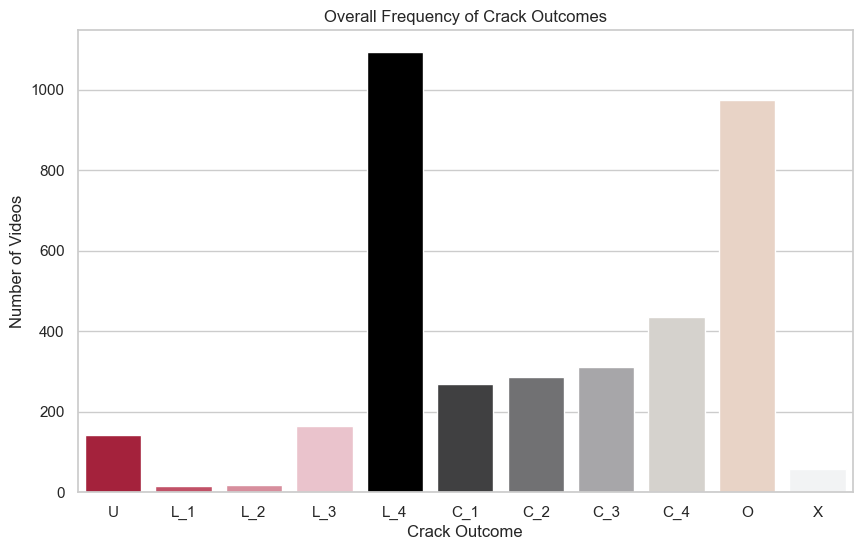

In [362]:
# Plot overall frequency with UGA palette
plt.figure(figsize=(10, 6))
sns.barplot(x=crack_outcome_cols, y=crack_counts[crack_outcome_cols].values, palette=uga_palette)  # x-axis categories  # y-axis heights  # custom color palette
plt.xlabel("Crack Outcome")
plt.ylabel("Number of Videos")
plt.title("Overall Frequency of Crack Outcomes")
plt.show()

In [363]:
# Define the 11 crack outcomes
crack_outcomes = ["U", "L_1", "L_2", "L_3", "L_4", "C_1", "C_2", "C_3", "C_4", "O", "X"]

# Define the 4 experimental factors
factors = ["moisture", "spring", "displacement", "motor"]

# Units / descriptive labels for axis labeling
factor_units = {"moisture": "Kernel Moisture (%)", "spring": "Spring Stiffness (N/mm)", "displacement": "Displacement Setting (in)", "motor": "Motor Speed (Hz)"}

outcome_labels = {"U": "Untouched", "L_1": "Longitudinal <25%", "L_2": "Longitudinal 25–50%", "L_3": "Longitudinal 50–75%", "L_4": "Longitudinal >75%", "C_1": "Circumferential <25%", "C_2": "Circumferential 25–50%", "C_3": "Circumferential 50–75%", "C_4": "Circumferential >75%", "O": "Open Crack", "X": "Crushed"}


### Mean Crack Outcome Percentages by Kernel Moisture (%) ###

   moisture      U   L_1   L_2    L_3    L_4    C_1    C_2    C_3    C_4  \
0         5   8.54  0.42  0.21   9.79  80.62  15.83  21.88  21.88  31.67   
1         7   4.59  1.67  1.88  11.27  79.96  17.33  22.13  20.46  36.53   
2         9  16.56  1.24  1.66  13.04  66.87  22.57  15.32  22.15  22.36   

       O     X  
0  73.12  3.96  
1  73.70  3.55  
2  56.11  4.55  


,moisture,U,L_1,L_2,L_3,L_4,C_1,C_2,C_3,C_4,O,X
0,5,8.541667,0.416667,0.208333,9.791667,80.625000,15.833333,21.875000,21.875000,31.666667,73.125000,3.958333
1,7,4.592902,1.670146,1.878914,11.273486,79.958246,17.327766,22.129436,20.459290,36.534447,73.695198,3.549061
2,9,16.563147,1.242236,1.656315,13.043478,66.873706,22.567288,15.320911,22.153209,22.360248,56.107660,4.554865


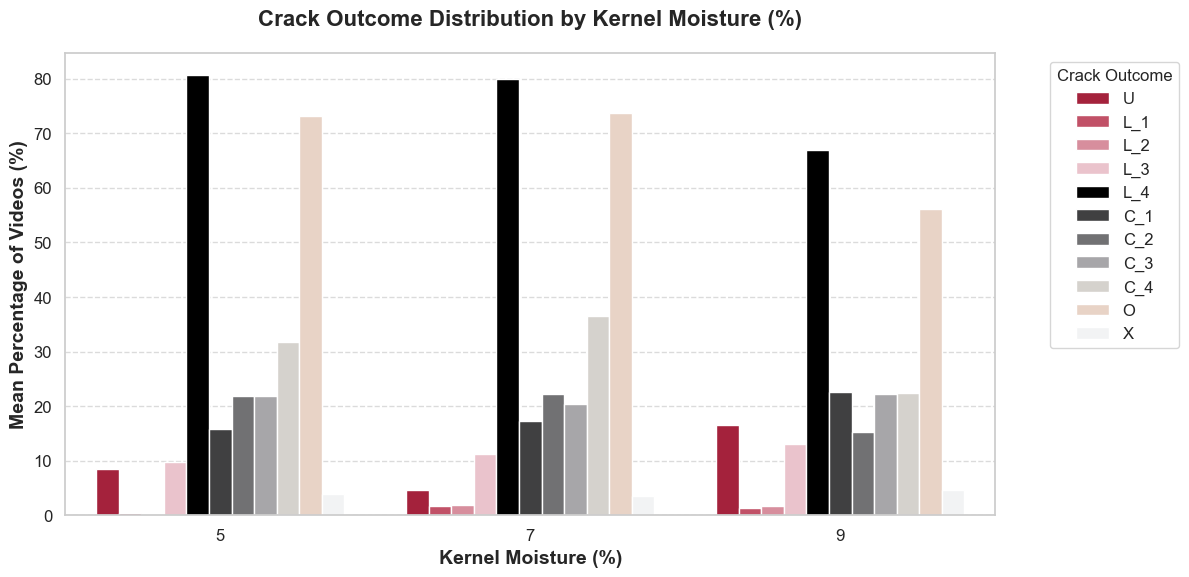


### Mean Crack Outcome Percentages by Spring Stiffness (N/mm) ###

   spring      U   L_1   L_2    L_3    L_4    C_1    C_2    C_3    C_4      O  \
0    1800  13.57  1.25  1.88   8.98  73.90  22.13  17.75  13.78  33.19  63.05   
1    2000  10.72  1.65  1.24  15.67  70.52  19.79  23.09  27.63  18.97  64.33   
2    2200   5.44  0.42  0.63   9.41  83.05  13.81  18.41  23.01  38.49  75.52   

      X  
0  4.80  
1  0.41  
2  6.90  


,spring,U,L_1,L_2,L_3,L_4,C_1,C_2,C_3,C_4,O,X
0,1800,13.569937,1.252610,1.878914,8.977035,73.903967,22.129436,17.745303,13.778706,33.194154,63.048017,4.801670
1,2000,10.721649,1.649485,1.237113,15.670103,70.515464,19.793814,23.092784,27.628866,18.969072,64.329897,0.412371
2,2200,5.439331,0.418410,0.627615,9.414226,83.054393,13.807531,18.410042,23.012552,38.493724,75.523013,6.903766


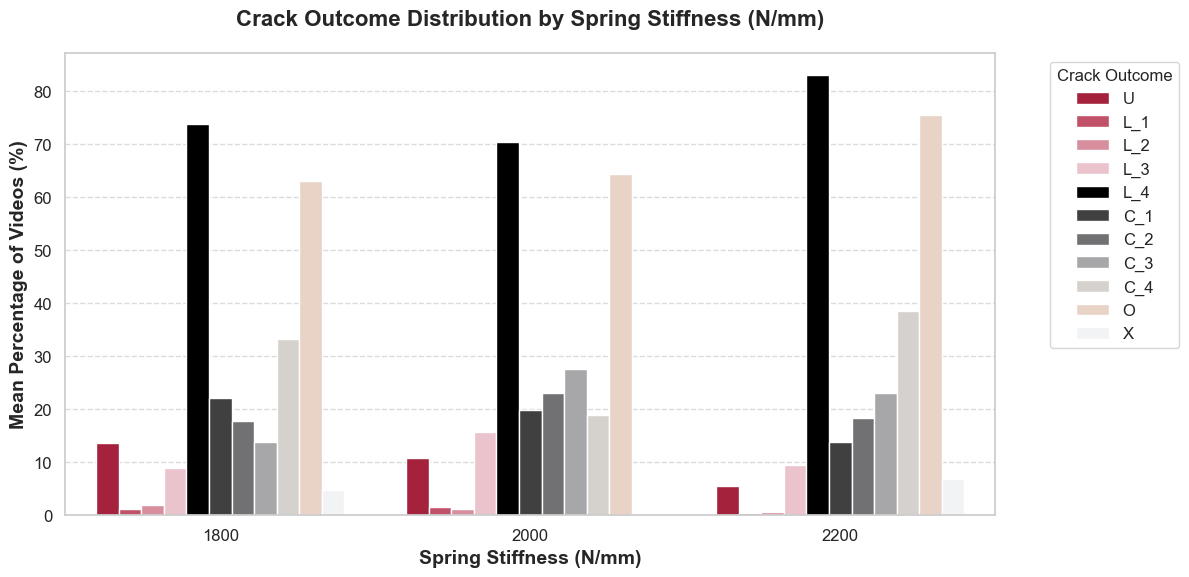


### Mean Crack Outcome Percentages by Displacement Setting (in) ###

   displacement      U   L_1   L_2    L_3    L_4    C_1    C_2    C_3    C_4  \
0          0.22   3.12  0.62  0.62   2.29  92.72   3.74   6.65  25.78  60.91   
1          0.29   5.39  0.83  1.45  11.20  80.29  12.66  31.54  30.71  19.71   
2          0.36  21.29  1.88  1.67  20.67  54.28  39.46  21.09   7.93   9.81   

       O     X  
0  90.23  4.57  
1  77.80  3.11  
2  34.66  4.38  


,displacement,U,L_1,L_2,L_3,L_4,C_1,C_2,C_3,C_4,O,X
0,0.22,3.118503,0.623701,0.623701,2.286902,92.723493,3.742204,6.652807,25.779626,60.914761,90.228690,4.573805
1,0.29,5.394191,0.829876,1.452282,11.203320,80.290456,12.655602,31.535270,30.705394,19.709544,77.800830,3.112033
2,0.36,21.294363,1.878914,1.670146,20.668058,54.279749,39.457203,21.085595,7.933194,9.812109,34.655532,4.384134


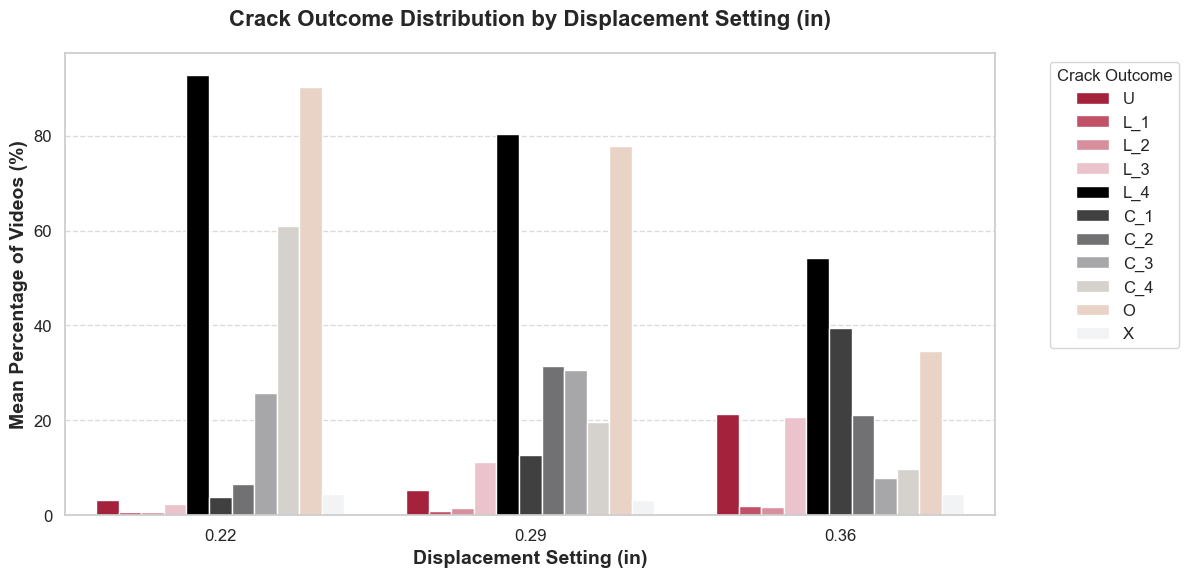


### Mean Crack Outcome Percentages by Motor Speed (Hz) ###

   motor      U   L_1   L_2    L_3    L_4    C_1    C_2    C_3    C_4      O  \
0     30   7.53  1.51  1.94  12.47  75.91  19.14  20.86  22.37  29.68  69.89   
1     45  13.31  0.81  1.01  11.90  71.98  21.37  17.54  18.35  29.44  60.89   
2     60   8.73  1.04  0.83   9.77  79.63  15.18  21.00  23.91  31.39  72.35   

      X  
0  3.23  
1  4.84  
2  3.95  


,motor,U,L_1,L_2,L_3,L_4,C_1,C_2,C_3,C_4,O,X
0,30,7.526882,1.505376,1.935484,12.473118,75.913978,19.139785,20.860215,22.365591,29.677419,69.892473,3.225806
1,45,13.306452,0.806452,1.008065,11.895161,71.975806,21.370968,17.540323,18.346774,29.435484,60.887097,4.838710
2,60,8.731809,1.039501,0.831601,9.771310,79.625780,15.176715,20.997921,23.908524,31.392931,72.349272,3.950104


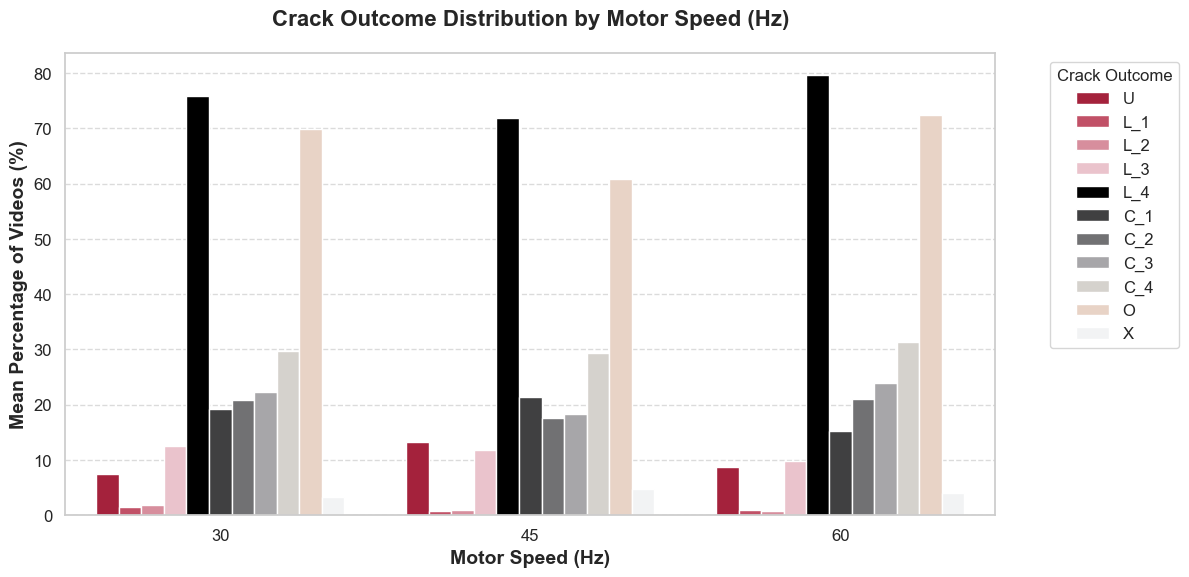

In [364]:
# 1) Group-Wise Summaries for All Factors
# We compute mean(=proportion) * 100 for each crack outcome by each factor's levels.


# Define a function for grouped bar plots
def plot_crack_outcomes_by_factor(df, factor):
    # Compute mean percentages
    grouped_factor = df.groupby(factor)[crack_outcomes].mean() * 100
    df_factor_reset = grouped_factor.reset_index()

    # Print exact percentages in table format
    print(f"\n### Mean Crack Outcome Percentages by {factor_units.get(factor, factor)} ###\n")
    print(df_factor_reset.round(2))  # Print the table
    display(df_factor_reset)

    # Convert from wide to long format for Seaborn
    factor_melted = pd.melt(df_factor_reset, id_vars=factor, value_vars=crack_outcomes, var_name="crack_outcome", value_name="percentage")

    # Create figure
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=factor, y="percentage", hue="crack_outcome", data=factor_melted, palette=uga_palette, hue_order=crack_outcomes)

    # Add labels with units if available
    xlabel = factor_units.get(factor, factor)
    ylabel = "Mean Percentage of Videos (%)"  # Standardized Y-axis

    plt.xlabel(xlabel, fontsize=14, fontweight="bold")
    plt.ylabel(ylabel, fontsize=14, fontweight="bold")

    # Enhance title
    plt.title(f"Crack Outcome Distribution by {xlabel}", fontsize=16, fontweight="bold", pad=20)

    # Improve legend placement
    plt.legend(title="Crack Outcome", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=12)

    # Improve tick label size
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Show grid for readability
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    plt.show()


# Generate professional plots for each experimental factor
for factor in factors:
    plot_crack_outcomes_by_factor(df_agg, factor)

In [365]:
# Create folders to store plots
os.makedirs("plots_single_factor", exist_ok=True)
os.makedirs("plots_pair_factors", exist_ok=True)
os.makedirs("plots_triple_factors", exist_ok=True)
os.makedirs("plots_quad_factors", exist_ok=True)

In [366]:
# Define helper functions for labeling subplots and generating safe titles and x-labels for plots
def label_subplot(ax, index, x_offset=-0.15, y_offset=1.10):
    label = f"({chr(97 + index)})"  # ASCII 97='a', 98='b', etc.
    ax.text(x_offset, y_offset, label, transform=ax.transAxes, fontsize=12, fontweight="bold", ha="left", va="top")


def safe_title(fA, fB=None, fC=None, fD=None):
    if fB is None:
        return f"{factor_units[fA]}"
    elif fC is None:
        return f"{factor_units[fA]} & {factor_units[fB]}"
    elif fD is None:
        return f"{factor_units[fA]}, {factor_units[fB]}, {factor_units[fC]}"
    else:
        return f"{factor_units[fA]}, {factor_units[fB]}, {factor_units[fC]}, {factor_units[fD]}"


def safe_xlabel(*factors_in):
    return "(" + ", ".join(factor_units[f] for f in factors_in) + ")"

In [367]:
# Single-Factor Subplots for All 11 Outcomes
def plot_single_factor_subplots(df, factor_col, outcomes, palette=uga_palette):
    """
    Creates a multi-subplot figure for all crack outcomes vs. a single factor_col.
    Each subplot is labeled (a), (b), ... outside the plot
    """
    n_outcomes = len(outcomes)
    nrows = (n_outcomes + 3) // 4  # 4 subplots per row
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False)
    axes = axes.flatten()

    for i, outcome in enumerate(outcomes):
        ax = axes[i]
        grouped_vals = df.groupby(factor_col)[outcome].mean() * 100
        df_reset = grouped_vals.reset_index().sort_values(by=factor_col)

        sns.barplot(x=factor_col, y=outcome, data=df_reset, palette=palette, ax=ax)

        # Add label OUTSIDE the plot
        label_subplot(ax, i)  # Pass fig here

        ax.set_xlabel(factor_units.get(factor_col, factor_col))
        ax.set_ylabel(f"% {outcome_labels.get(outcome, outcome)}")
        ax.set_ylim(0, 105)

    # Hide unused subplots
    total_subplots = nrows * ncols
    if n_outcomes < total_subplots:
        for j in range(n_outcomes, total_subplots):
            fig.delaxes(axes[j])

    # Main title and layout
    fig.suptitle(f"Figure: All Crack Outcomes vs. {factor_units.get(factor_col, factor_col)}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle

    fig.savefig(f"plots_single_factor/{factor_col}_all_outcomes.png", dpi=150)
    plt.close(fig)


# Generate subplots for each single factor
for fcol in factors:
    plot_single_factor_subplots(df_agg, fcol, crack_outcomes, uga_palette)

C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\105995707.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\105995707.py:18: UserWarning: The palette list has more values (11) than needed (3), which may not be intended.
  sns.barplot(x=factor_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\105995707.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factor_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\105995707.py:18: UserWarning: The palette list

In [368]:
# Pairwise-Factor Subplots
pairwise_combos = [("moisture", "spring"), ("moisture", "displacement"), ("moisture", "motor"), ("spring", "displacement"), ("spring", "motor"), ("displacement", "motor")]


def plot_pairwise_subplots(df, fA, fB, outcomes, palette=uga_palette):
    combo_col = f"{fA}_{fB}"
    # Build the composite factor
    df[combo_col] = df[fA].astype(str) + "_" + df[fB].astype(str)

    n_outcomes = len(outcomes)
    nrows = (n_outcomes + 3) // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False)
    axes = axes.flatten()

    for i, outcome in enumerate(outcomes):
        ax = axes[i]
        grouped_vals = df.groupby(combo_col)[outcome].mean() * 100
        df_reset = grouped_vals.reset_index().sort_values(by=combo_col)

        sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
        label_subplot(ax, i)
        ax.set_xlabel(safe_xlabel(fA, fB))
        ax.set_ylabel(f"% {outcome_labels.get(outcome, outcome)}")
        ax.set_ylim(0, 105)
        ax.set_title(f"{outcome_labels.get(outcome, outcome)}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

    if n_outcomes < len(axes):
        for j in range(n_outcomes, len(axes)):
            fig.delaxes(axes[j])

    fig.suptitle(f"Figure: All Outcomes vs. {safe_title(fA, fB)}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    # Save figure
    outname = f"{fA}_{fB}_all_outcomes.png"
    fig.savefig(os.path.join("plots_pair_factors", outname), dpi=150)
    plt.close(fig)

    # remove composite col
    df.drop(columns=[combo_col], inplace=True)


for fA, fB in pairwise_combos:
    plot_pairwise_subplots(df_agg, fA, fB, crack_outcomes, uga_palette)

C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\662386980.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\662386980.py:21: UserWarning: The palette list has more values (11) than needed (9), which may not be intended.
  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\662386980.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\662386980.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be

In [369]:
# Triple-Factor Subplots
triple_combos = [("moisture", "spring", "displacement"), ("moisture", "spring", "motor"), ("moisture", "displacement", "motor"), ("spring", "displacement", "motor")]


def plot_triple_subplots(df, fA, fB, fC, outcomes, palette=uga_palette):
    combo_col = f"{fA}_{fB}_{fC}"
    df[combo_col] = df[fA].astype(str) + "_" + df[fB].astype(str) + "_" + df[fC].astype(str)

    n_outcomes = len(outcomes)
    nrows = (n_outcomes + 3) // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False)
    axes = axes.flatten()

    for i, outcome in enumerate(outcomes):
        ax = axes[i]
        grouped_vals = df.groupby(combo_col)[outcome].mean() * 100
        df_reset = grouped_vals.reset_index().sort_values(by=combo_col)

        sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
        label_subplot(ax, i)
        ax.set_xlabel(safe_xlabel(fA, fB, fC))
        ax.set_ylabel(f"% {outcome_labels.get(outcome, outcome)}")
        ax.set_ylim(0, 105)
        ax.set_title(f"{outcome_labels.get(outcome, outcome)}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha="right", fontsize=7)

    if n_outcomes < len(axes):
        for j in range(n_outcomes, len(axes)):
            fig.delaxes(axes[j])

    fig.suptitle(f"Figure: All Outcomes vs. {safe_title(fA, fB, fC)}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outname = f"{fA}_{fB}_{fC}_all_outcomes.png"
    fig.savefig(os.path.join("plots_triple_factors", outname), dpi=150)
    plt.close(fig)

    df.drop(columns=[combo_col], inplace=True)


for a, b, c in triple_combos:
    plot_triple_subplots(df_agg, a, b, c, crack_outcomes, uga_palette)

C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\576823774.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\576823774.py:20: UserWarning: 
The palette list has fewer values (11) than needed (27) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\576823774.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65, ha="right", fontsize=7)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\576823774.py:20: FutureWarning: 

Passing `palette` without assigni

In [370]:
# Quadruple-Factor Subplots
quad_factors = ("moisture", "spring", "displacement", "motor")


def plot_quad_subplots(df, fA, fB, fC, fD, outcomes, palette=uga_palette):
    combo_col = f"{fA}_{fB}_{fC}_{fD}"
    df[combo_col] = df[fA].astype(str) + "_" + df[fB].astype(str) + "_" + df[fC].astype(str) + "_" + df[fD].astype(str)

    n_outcomes = len(outcomes)
    nrows = (n_outcomes + 3) // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharey=False)
    axes = axes.flatten()

    for i, outcome in enumerate(outcomes):
        ax = axes[i]
        grouped_vals = df.groupby(combo_col)[outcome].mean() * 100
        df_reset = grouped_vals.reset_index().sort_values(by=combo_col)

        sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
        label_subplot(ax, i)
        ax.set_xlabel(safe_xlabel(fA, fB, fC, fD))
        ax.set_ylabel(f"% {outcome_labels.get(outcome, outcome)}")
        ax.set_ylim(0, 105)
        ax.set_title(f"{outcome_labels.get(outcome, outcome)}")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha="right", fontsize=6)

    if n_outcomes < len(axes):
        for j in range(n_outcomes, len(axes)):
            fig.delaxes(axes[j])

    fig.suptitle(f"Figure: All Outcomes vs. {safe_title(fA, fB, fC, fD)}", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    outname = f"{fA}_{fB}_{fC}_{fD}_all_outcomes.png"
    fig.savefig(os.path.join("plots_quad_factors", outname), dpi=150)
    plt.close(fig)

    df.drop(columns=[combo_col], inplace=True)


plot_quad_subplots(df_agg, quad_factors[0], quad_factors[1], quad_factors[2], quad_factors[3], crack_outcomes)

C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\4004724732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\4004724732.py:20: UserWarning: 
The palette list has fewer values (11) than needed (81) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=combo_col, y=outcome, data=df_reset, palette=palette, ax=ax)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\4004724732.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha="right", fontsize=6)
C:\Users\nr77309\AppData\Local\Temp\ipykernel_17156\4004724732.py:20: FutureWarning: 

Passing `palette` without ass